In [4]:
# import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

Matplotlib is building the font cache; this may take a moment.


In [9]:
#constant
FILE_PATH = Path("C:/Users/mehak taj/OneDrive/Desktop/Project/air_quality_data.csv")
CITY = 'Delhi'
POLLUTANTS = ['PM2.5','PM10','NO2','SO2','CO','O3']

In [10]:
# Load data
def load_data(file_path):
    '''load dataset from specified path'''
    try:
        data = pd.read_csv(file_path)
        print('dataset loaded successfully.')
        return data
    except FileNotFoundError:
        print(f'File Not Found at {file_path}, please recheck the path.')
        raise
    except Exception as e:
        print('Error:',e)
        raise
#loading the dataset
data = load_data(FILE_PATH)

dataset loaded successfully.


In [12]:
# filtering for specific city
def filter_data(data, city):
    '''Filter the data for specific city'''
    filter_data = data[data['City'] == city].copy()
    print(f'successfully Filtered for city: {city}')
    return filter_data

#filter for Delhi
delhi_data = filter_data(data, CITY)

successfully Filtered for city: Delhi


In [13]:
delhi_data

,City,Date,AQI,PM2.5,PM10,NO2,SO2,CO,O3
0,Delhi,2023-01-01,377,36.7,227.6,28.3,8.7,0.4,91.5
1,Delhi,2023-01-02,329,30.9,138.1,7.8,12.5,1.4,12.9
2,Delhi,2023-01-03,151,181.8,216.4,44.9,23.6,0.8,105.6
3,Delhi,2023-01-04,438,203.4,215.5,37.3,9.5,2.4,47.0
4,Delhi,2023-01-05,97,101.2,120.5,37.7,14.7,0.3,60.5
...,...,...,...,...,...,...,...,...,...
360,Delhi,2023-12-27,429,68.5,68.8,20.2,28.9,2.4,35.5
361,Delhi,2023-12-28,257,161.1,72.2,67.4,21.0,1.9,107.1
362,Delhi,2023-12-29,280,152.1,128.9,71.9,11.9,1.9,99.0
363,Delhi,2023-12-30,82,148.6,243.9,56.0,19.6,0.7,22.5


In [14]:
#clean data
def clean_data(data):
    data.loc[:,'Date'] = pd.to_datetime(data['Date'])
    data.loc[:,'AQI'] = data['AQI'].fillna(data['AQI'].mean())
    print('Data cleansed successfully.')
    return data

#cleaning data
delhi_data = clean_data(delhi_data)

Data cleansed successfully.


In [18]:
# categorize AQI
def categorize_aqi(aqi):
    '''categorize aqi to various groups for health risks'''
    if aqi <= 50:
        return 'Goog'
    elif aqi <= 100:
        return 'moderate'
    elif aqi <= 150:
        return 'Unhealthy for sensitive Group'
    elif aqi <= 200:
        return 'Unhealthy'
    elif aqi <= 300:
        return 'very unhealthy'
    else:
        return 'Hazardous'

# add column AQI category to delhi dataframe
delhi_data.loc[:, 'AQI Category'] = delhi_data['AQI'].apply(categorize_aqi)
print("done")

done


In [19]:
delhi_data.head()

,City,Date,AQI,PM2.5,PM10,NO2,SO2,CO,O3,AQI Category
0,Delhi,2023-01-01 00:00:00,377,36.7,227.6,28.3,8.7,0.4,91.5,Hazardous
1,Delhi,2023-01-02 00:00:00,329,30.9,138.1,7.8,12.5,1.4,12.9,Hazardous
2,Delhi,2023-01-03 00:00:00,151,181.8,216.4,44.9,23.6,0.8,105.6,Unhealthy
3,Delhi,2023-01-04 00:00:00,438,203.4,215.5,37.3,9.5,2.4,47.0,Hazardous
4,Delhi,2023-01-05 00:00:00,97,101.2,120.5,37.7,14.7,0.3,60.5,moderate


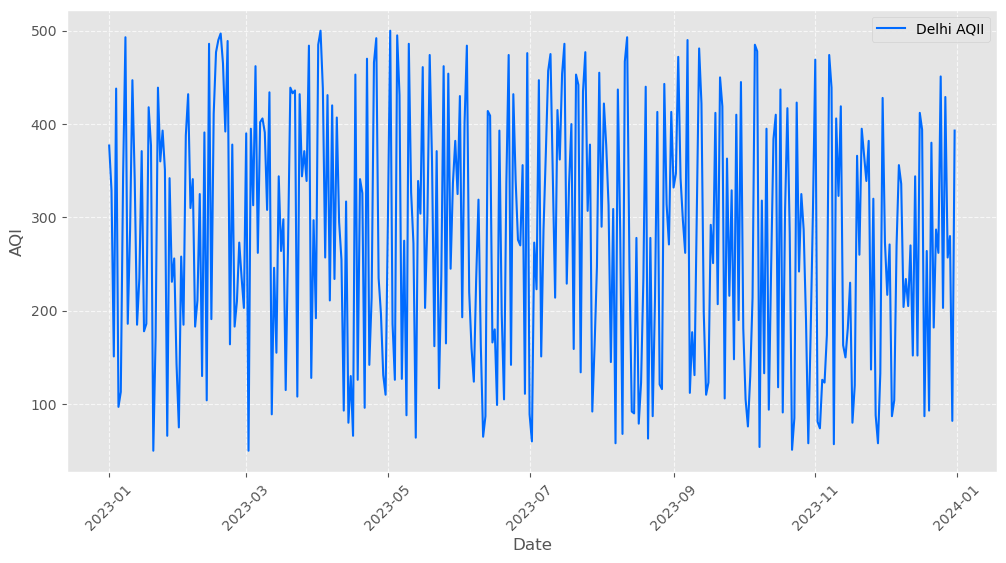

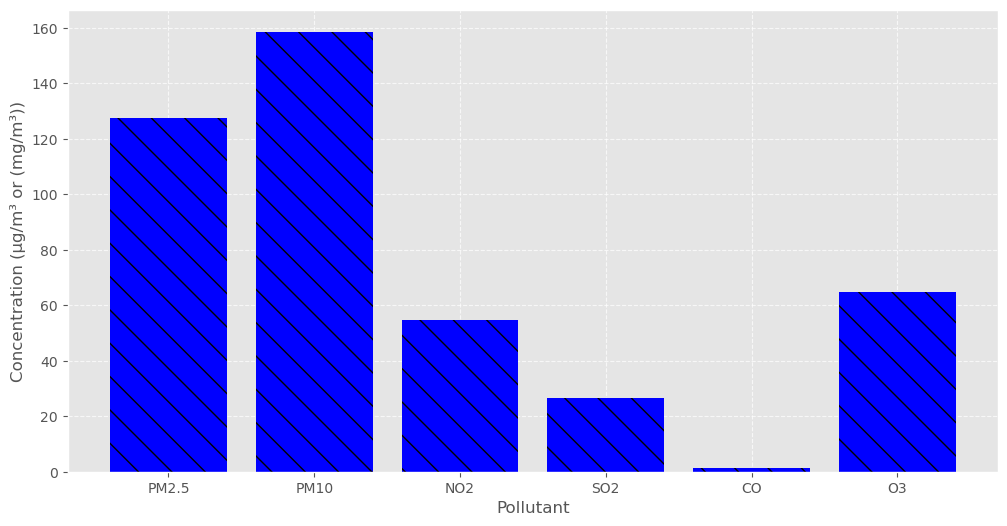

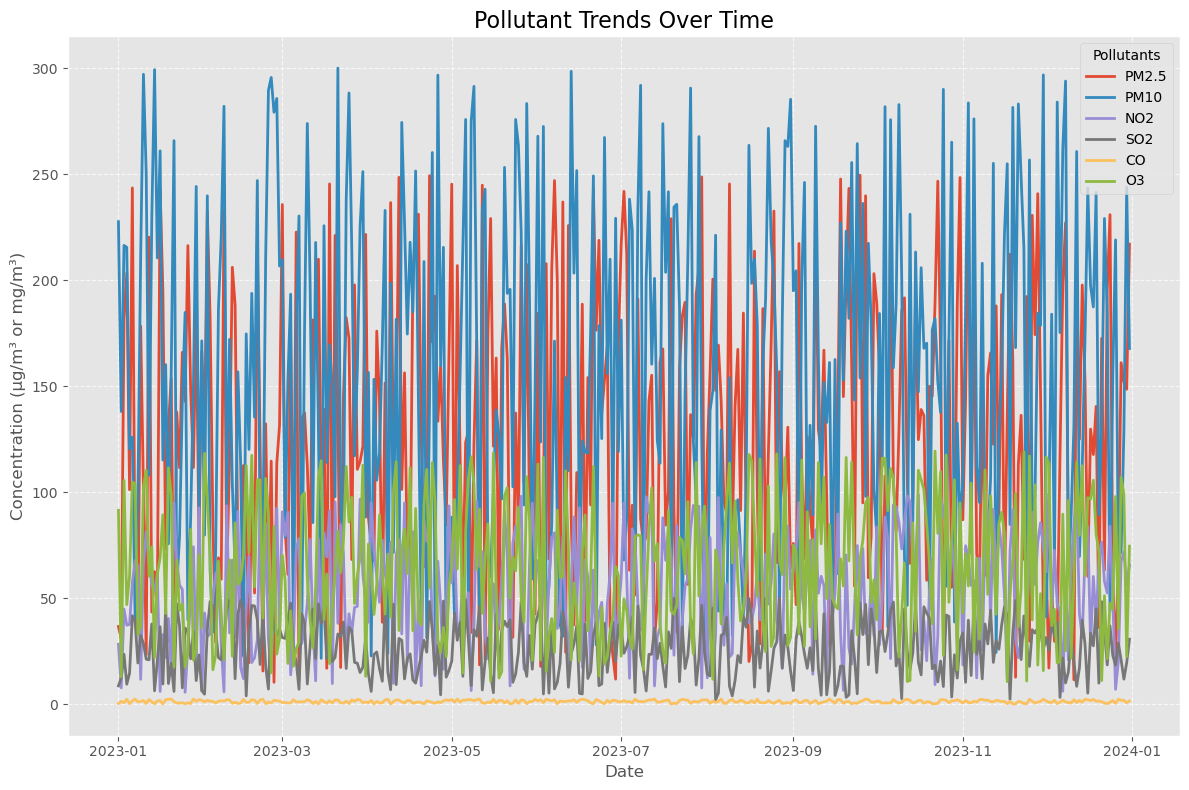

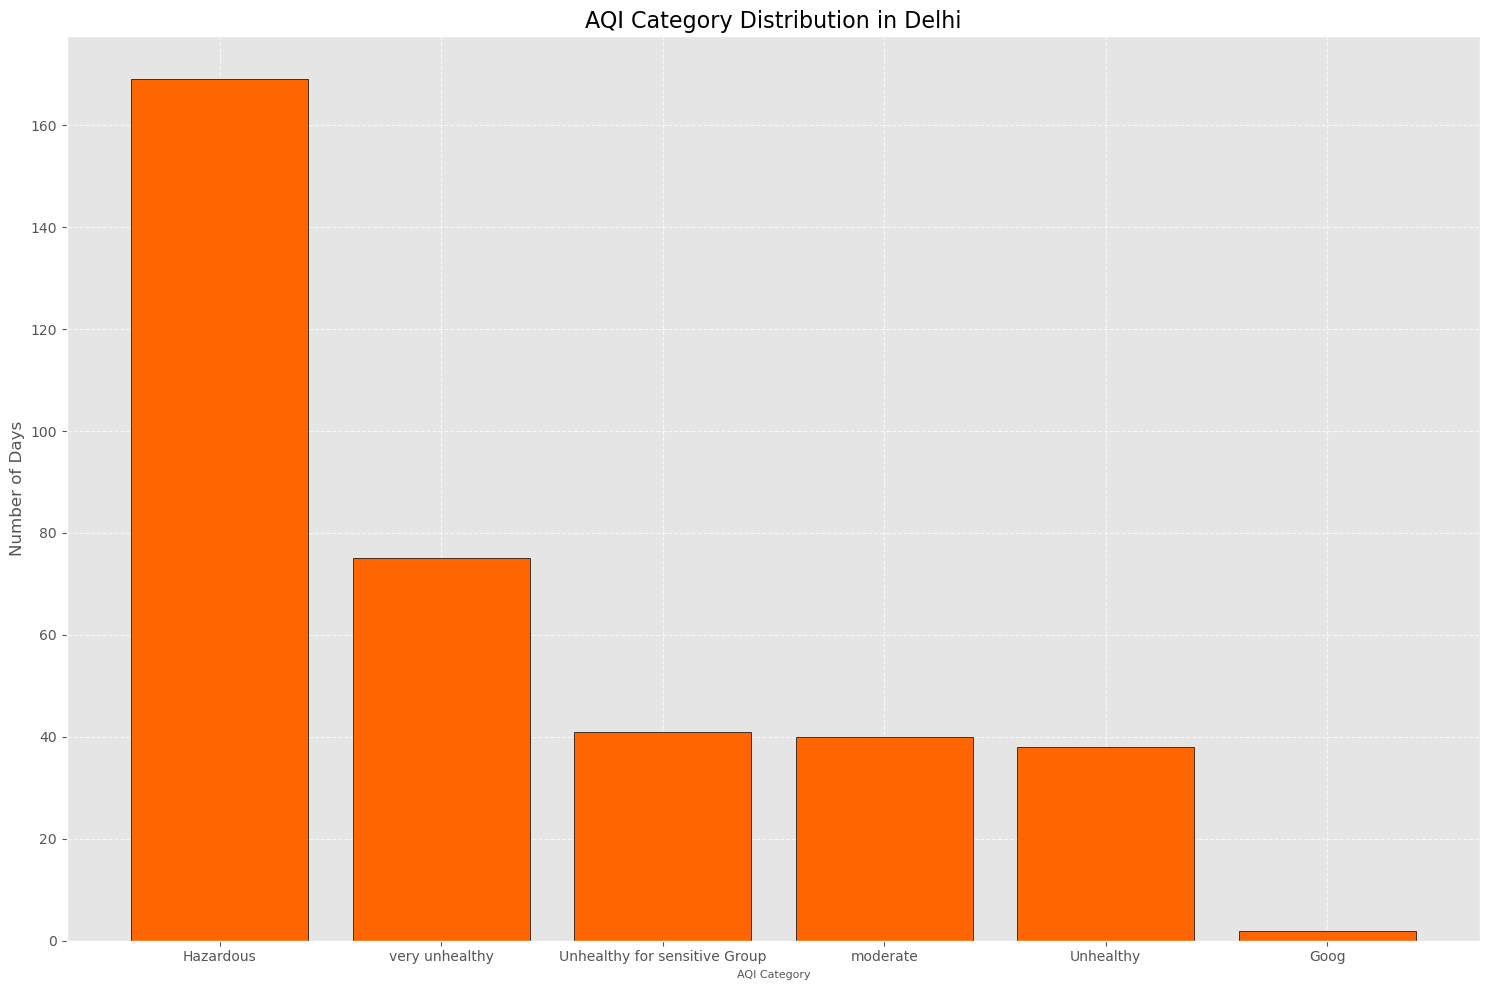

In [25]:
# analyze and visualize
def analyze_and_visualize(data,pollutants):

    plt.style.use('ggplot')

    # Daily AQI trend for delhi
    daily_aqi = data.groupby("Date") ['AQI'].mean()
    plt.figure(figsize=(12,6))
    plt.plot(daily_aqi.index,daily_aqi.values, color='#006BFF',label='Delhi AQII')
    plt.xlabel('Date',fontsize=12)
    plt.ylabel('AQI',fontsize=12)
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, linestyle='--',alpha=0.7)
    plt.savefig("C:/Users/mehak taj/OneDrive/Desktop/Project/report image/daily_aqi_delhi.png",dpi=300,format='png')
    plt.show()

    # Avearge Pollutants level in Delhi
    pollutant = data[pollutants].mean()
    plt.figure(figsize=(12, 6))
    plt.bar(pollutant.index, pollutant.values, color='blue', hatch='\\')
    # pollutant = {'pm2.5'= mean(pm2.5)}
    plt.xlabel('Pollutant', fontsize=12)
    plt.ylabel('Concentration (µg/m³ or (mg/m³))', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    # plt.savefig(path, dpi=290, format=png)
    plt.savefig("C:/Users/mehak taj/OneDrive/Desktop/Project/report image/average_pollutant_level.png", dpi=300, format='png')
    plt.show()


    
    plt.figure(figsize=(12, 8))
    for pollutant in pollutants:
        if pollutant in data.columns:
            plt.plot(data['Date'], data[pollutant], label=pollutant, linewidth=2)
    plt.title("Pollutant Trends Over Time", fontsize=16)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Concentration (µg/m³ or mg/m³)", fontsize=12)
    plt.legend(title="Pollutants", fontsize=10)
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.savefig("C:/Users/mehak taj/OneDrive/Desktop/Project/report image/average_pollutant_levels_trends.png", dpi=300, format='png')
    plt.show()




# AQI category distribution
    aqi_category_counts = data["AQI Category"].value_counts()
    plt.figure(figsize=(15, 10))
    plt.bar(aqi_category_counts.index, aqi_category_counts.values, color="#FF6500", edgecolor="black")
    # {Good: 20}
    plt.title("AQI Category Distribution in Delhi", fontsize=16)
    plt.xlabel("AQI Category", fontsize=8)
    plt.ylabel("Number of Days", fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.savefig("C:/Users/mehak taj/OneDrive/Desktop/Project/report image/aqi_category_distribution.png", dpi=300, format='png')
    plt.show()


    


analyze_and_visualize(delhi_data, POLLUTANTS)